# Boilerplate

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import warnings

from IPython.core.debugger import set_trace
from IPython.core.interactiveshell import InteractiveShell
from IPython.display import display, Markdown, HTML, Javascript
from tqdm import tqdm


def alert(message='Loop completed!'):
    # Check if the system supports 'say' and notifications
    os.system(f'osascript -e \'display notification "{message}" with title "Notification"\'')
    # Speak the alert
    os.system(f'say "{message}"')

os.environ['PYTHONBREAKPOINT'] = 'IPython.core.debugger.set_trace'
breakpoint = set_trace
InteractiveShell.ast_node_interactivity = "all"
warnings.filterwarnings("ignore")
tqdm.pandas()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Analysis

In [ ]:
!pip install retry
!pip install markdownify

In [ ]:
from retry import retry
import pandas as pd
import requests
from bs4 import BeautifulSoup
from markdownify import markdownify as md

URL = 'https://ballotpedia.org/{}_2024_local_ballot_measures'

In [ ]:
turnout_df = pd.read_csv('data/archive/turnout_20241112.csv')
df = turnout_df
df

,State,County,district,zip,complexity,grade_level,population,state_id,unique_decisions,measures,races,comp_races,grpName,Lit_A,turnout,score
0,Texas,Waller,TX-CD10,77494,0.302581,18.8,129165.0,TX,34,0,34,26,all,242.0,0.468929,2.641322
1,Texas,Harris,TX-CD22,77494,0.641739,20.1,129165.0,TX,98,26,72,59,all,247.8,0.036387,7.949153
2,Texas,Fort Bend,TX-CD22,77494,0.365415,17.7,129165.0,TX,32,0,32,25,all,273.4,0.084843,2.071690
3,Texas,Harris,TX-CD08,77449,0.640797,20.1,119994.0,TX,98,26,72,58,all,247.8,0.036387,7.949153
4,Texas,Harris,TX-CD22,77449,0.641739,20.1,119994.0,TX,98,26,72,59,all,247.8,0.036387,7.949153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47723,Massachusetts,Franklin,MA-CD02,1096,0.195223,18.3,NaN,MA,11,5,6,4,all,276.8,0.016596,0.727240
47724,Massachusetts,Franklin,MA-CD02,1367,0.195223,18.3,NaN,MA,11,5,6,4,all,276.8,0.016596,0.727240
47725,Massachusetts,Franklin,MA-CD02,1331,0.192502,18.5,NaN,MA,11,5,6,3,all,276.8,0.016596,0.735188
47726,Massachusetts,Franklin,MA-CD01,1370,0.190640,17.1,NaN,MA,11,5,6,4,all,276.8,0.016596,0.679552


In [ ]:
STATES = list(df.State.unique())
print(STATES)

['Texas', 'New York', 'California', 'Illinois', 'Tennessee', 'Georgia', 'Washington', 'Virginia', 'Hawaii', 'Florida', 'Oklahoma', 'North Carolina', 'Arizona', 'Kansas', 'Colorado', 'New Mexico', 'Missouri', 'Utah', 'Pennsylvania', 'Nevada', 'Indiana', 'Oregon', 'Ohio', 'Idaho', 'Maryland', 'District of Columbia', 'Michigan', 'South Carolina', 'Kentucky', 'Delaware', 'Wisconsin', 'Minnesota', 'Louisiana', 'Arkansas', 'Montana', 'Alabama', 'Mississippi', 'North Dakota', 'South Dakota', 'Nebraska', 'Iowa', 'Alaska', 'West Virginia', 'Wyoming', 'Massachusetts', 'Vermont', 'New Jersey', 'New Hampshire', 'Maine', 'Rhode Island']


In [ ]:
from functools import lru_cache

def get_measure_level(name):
    if "School District" in name:
        return "school-district-level"
    if "Utility District" in name or "City" in name or "Municipal" in name:
        return "municipal-level"
    if "County" in name:
        return "county-level"
    return "township-level"

def table_to_markdown(table):
    cell = table.find("td")
    return md(str(cell)) if cell else ""

def get_next_table(tag):
    return tag.find_next_sibling("table")

def process_measures(soup):
    results = []
    for p in soup.find_all("p"):
        a = p.find("a")
        if not a:
            continue

        url = a.get("href")
        if not url.startswith('https://ballotpedia'):
            continue

        name = a.get_text(strip=True)
        span = p.find("span")
        passed = (span and "✔" in span.get_text())
        yes_table = p.find_next_sibling("table")
        no_table = get_next_table(yes_table) if yes_table else None
        yes_vote = table_to_markdown(yes_table) if yes_table else ""
        no_vote = table_to_markdown(no_table) if no_table else ""
        level = get_measure_level(name)
        results.append({
            "measure_url": url,
            "measure_name": name,
            "level": level,
            "yes_vote": yes_vote,
            "no_vote": no_vote,
            "passed": passed
        })
    return results


@lru_cache
def get_measures(state):
    response = requests.get(URL.format(state))
    if response.status_code != 200: return None
    soup = BeautifulSoup(response.text)
    new_rows = process_measures(soup)
    new_rows = [{'state': state, 'state_url': URL.format(state), **r} for r in new_rows]
    time.sleep(1)
    return new_rows

In [ ]:
import time
rows = []
for state in STATES:
    print('======================')
    state = state.replace(' ', '_')
    print(state)

    new_rows = get_measures(state)
    if not new_rows: continue

    print(pd.DataFrame(new_rows).dropna().level.value_counts())
    rows.extend(new_rows)


NameError: name 'STATES' is not defined

In [ ]:
measure_df = pd.DataFrame(rows).dropna()
measure_df.level.value_counts()

AttributeError: 'DataFrame' object has no attribute 'level'

In [ ]:
from bs4 import BeautifulSoup
import re
import requests
import time

def get_measure_title(soup):
    title_tag = soup.find('h1', {'id': 'firstHeading'})
    return title_tag.get_text(strip=True) if title_tag else ""

def get_ballot_text(soup, url=None):
    ballot_title_section = soup.find(lambda tag: tag.name == 'h3' and 'Ballot title' in tag.text)
    if not ballot_title_section:
        ballot_title_section = soup.find(lambda tag: tag.name == 'h3' and 'Ballot question' in tag.text)
    if not ballot_title_section:
        ballot_title_section = soup.find(lambda tag: tag.name == 'h3' and 'Long ballot title' in tag.text)
    if not ballot_title_section:
        breakpoint()
        return ""
    quote_table = ballot_title_section.find_next('table')
    if not quote_table:
        breakpoint()
    return quote_table.get_text(strip=True).replace('"', '').strip() if quote_table else ""

def get_yes_vote_meaning(soup):
    yes_vote_table = soup.find('table', style=lambda style: style and 'border-left: 10px solid #007F00' in style)
    if not yes_vote_table:
        return ""
    yes_text = yes_vote_table.get_text(strip=True)
    # Format the text properly with spaces
    yes_text = re.sub(r'A\s*"yes"\s*vote\s*supported', 'A "yes" vote supported ', yes_text)
    return yes_text.strip()

def get_no_vote_meaning(soup):
    no_vote_table = soup.find('table', style=lambda style: style and 'border-left: 10px solid #BF0000' in style)
    if not no_vote_table:
        return ""
    no_text = no_vote_table.get_text(strip=True)
    # Format the text properly with spaces
    no_text = re.sub(r'A\s*"no"\s*vote\s*opposed', 'A "no" vote opposed ', no_text)
    return no_text.strip()

def get_election_results(soup):
    results = {'yes_votes': "", 'yes_percentage': "", 'no_votes': "", 'no_percentage': "", 'passed': False}
    results_section = soup.find('h2', string=lambda text: text and 'Election results' in text)
    if not results_section:
        return results

    results_table = results_section.find_next('table')
    if not results_table:
        return results

    rows = results_table.find_all('tr')
    yes_row = next((row for row in rows if 'Yes' in row.get_text()), None)
    no_row = next((row for row in rows if (
        'No' in row.get_text() and
        'No.' not in row.get_text() and
        'Nov' not in row.get_text() and
        'Nor' not in row.get_text() and
        ' No' not in row.get_text().strip()
    )), None)

    if yes_row:
        yes_cells = yes_row.find_all('td')
        if len(yes_cells) >= 3:
            results['yes_votes'] = yes_cells[-2].get_text(strip=True)
            results['yes_percentage'] = yes_cells[-1].get_text(strip=True)

    if no_row:
        no_cells = no_row.find_all('td')
        if len(no_cells) >= 3:
            results['no_votes'] = no_cells[-2].get_text(strip=True)
            results['no_percentage'] = no_cells[-1].get_text(strip=True)

    if not results['no_percentage']:
        breakpoint()

    results['passed'] = no_row and 'Defeated' not in no_row.get_text()

    return results

def get_path_to_ballot(soup):
    path_section = soup.find('h2', string=lambda text: text and 'Path to the ballot' in text)
    if not path_section:
        return ""

    next_p = path_section.find_next('p')
    return next_p.get_text(strip=True) if next_p else ""

def parse_measure_page(html_content, url=None):
    soup = BeautifulSoup(html_content, 'html.parser')

    results = {
        'title': get_measure_title(soup),
        'ballot_text': get_ballot_text(soup, url),
        'yes_vote_meaning': get_yes_vote_meaning(soup),
        'no_vote_meaning': get_no_vote_meaning(soup),
        'path_to_ballot': get_path_to_ballot(soup)
    }

    results.update(get_election_results(soup))

    return results

In [ ]:
@lru_cache(maxsize=10_000)
# @retry(delay=1, backoff=2, tries=10)
def fetch_measure_details(measure_url):
    response = requests.get(measure_url)

    if response.status_code != 200:
        error = {'error': f"Failed to fetch: {response.status_code}", 'measure_url': measure_url}
        print(error)
        response.raise_for_status()
        raise

    details = parse_measure_page(response.text, measure_url)
    details['measure_url'] = measure_url

    time.sleep(5)  # Be nice to the server
    return details

In [ ]:
from requests import HTTPError

In [ ]:
@lru_cache(maxsize=10_000)
def fetch_measure_details_safe(measure_url):
    if 'California' in measure_url:
        response = requests.get(measure_url)
        if response.status_code == 404:
            print(measure_url)
            return None
    try:
        return fetch_measure_details(measure_url)
    except HTTPError:
        response = requests.get(measure_url)
        if response.status_code == 404:
            print(measure_url)
            return None
        else:
            response.raise_for_status()


In [ ]:
fetch_bad_urls('https://ballotpedia.org/Montpelier_Roxbury_School_District,_Vermont,_Article_6,_School_District_Appropriation_to_Capital_Reserve_Fund_Measure_(March_2024)')

{'title': 'Montpelier Roxbury School District, Vermont, Article 6, School District Appropriation to Capital Reserve Fund Measure (March 2024)',
 'ballot_text': '“Shall the voters of the school district appropriate $270,000 necessary to supplement the Capital Reserve Fund in support of the District?”',
 'yes_vote_meaning': 'A "yes" vote supported spending $270,000 to supplement the Montpelier Roxbury School District\'s Capital Reserve Fund.',
 'no_vote_meaning': 'A "no" vote opposed spending $270,000 to supplement the Montpelier Roxbury School District\'s Capital Reserve Fund.',
 'path_to_ballot': 'This measure was put on the ballot through a vote of the governing body of Montpelier.',
 'yes_votes': '1,519',
 'yes_percentage': '57.47%',
 'no_votes': '1,124',
 'no_percentage': '42.53%',
 'passed': True,
 'measure_url': 'https://ballotpedia.org/Montpelier_Roxbury_School_District,_Vermont,_Article_6,_School_District_Appropriation_to_Capital_Reserve_Fund_Measure_(March_2024)'}

In [ ]:
@lru_cache(maxsize=10_000)
def fetch_bad_urls(measure_url):
    if measure_url not in BAD_URLS:
        return fetch_measure_details_safe(measure_url)

    response = requests.get(measure_url)

    if response.status_code != 200:
        error = {'error': f"Failed to fetch: {response.status_code}", 'measure_url': measure_url}
        response.raise_for_status()
        raise

    details = parse_measure_page(response.text)
    details['measure_url'] = measure_url

    time.sleep(1)  # Be nice to the server
    if not details.get('no_percentage'):
        print(measure_url)
        print(details)
        breakpoint()
        details = parse_measure_page(response.text)
        details['measure_url'] = measure_url
    return details

In [ ]:
measure_detail_df = pd.DataFrame(measure_df.measure_url.progress_apply(
        lambda x: fetch_bad_urls(x) or {'measure_url': x, 'title': None}
    ).to_list()
).drop(columns='passed')

100%|█| 1399/1399 [00:41<00:00, 33.31it/


In [ ]:
measure_detail_df['measure_url'] = measure_df.measure_url.to_list()
measure_data_df = measure_df.set_index('measure_url').join(
    measure_detail_df.set_index('measure_url')
).reset_index()
measure_data_df = measure_data_df[[measure_data_df.columns[1]] + list(measure_data_df.columns[3:]) + ['state_url', 'measure_url']]
measure_data_df = measure_data_df.drop_duplicates(['measure_url', 'measure_name'])
measure_data_df.to_csv('data/archive/measures_20250305.csv', index=False)

In [ ]:
BAD_URLS = data_df[data_df.no_percentage.fillna(False).apply(lambda x: not x)].measure_url.to_list()
BAD_URLS

['https://ballotpedia.org/Buellton,_California,_Measure_C2024,_Expand_Urban_Growth_Boundary_Measure_(November_2024)',
 'https://ballotpedia.org/Buellton,_California,_Measure_D2024,_Hotel_Tax_Increase_Measure_(November_2024)',
 'https://ballotpedia.org/Carpinteria,_California,_Measure_B2024,_Hotel_Tax_Increase_Measure_(November_2024)',
 'https://ballotpedia.org/College_School_District,_California,_Measure_L2024,_School_Bond_Measure_(November_2024)',
 'https://ballotpedia.org/Goleta,_California,_Measure_G2024,_Heritage_Farmlands_Program_Initiative_(November_2024)',
 'https://ballotpedia.org/Hope_School_District,_California,_Measure_Y2024,_School_Bond_Measure_(November_2024)',
 'https://ballotpedia.org/Lompoc,_California,_Measure_R2024,_Discontinue_Public_Park_Use_at_Ken_Adam_Park_Initiative_(November_2024)',
 'https://ballotpedia.org/Lompoc_Unified_School_District,_California,_Measure_M2024,_School_Bond_Measure_(November_2024)',
 'https://ballotpedia.org/Santa_Barbara,_California,_Measur

# Join measure data to full ballot data

In [ ]:
measure_data_df = pd.read_csv('data/archive/measures_20250305.csv')

In [ ]:
data_df = pd.read_csv('data/archive/data_20241119.csv')

In [ ]:
import textstat

data_df['ballot'] = data_df.full_markdown.apply(lambda x: x.partition('\n---\n')[-1])
data_df['dale_chall_before'] = data_df.ballot.progress_apply(textstat.dale_chall_readability_score_v2)
data_df['fkg_before'] = data_df.ballot.progress_apply(textstat.flesch_kincaid_grade)
data_df['fkg_percentile_before'] = data_df.fkg_before.rank(pct=True)
data_df['dc_percentile_before'] = data_df.dale_chall_before.rank(pct=True)
alert('done!')

100%|█| 50579/50579 [00:13<00:00, 3676.8
100%|█| 50579/50579 [00:11<00:00, 4327.4


In [ ]:
import requests
from bs4 import BeautifulSoup, Tag
import json
import re
from typing import List, Dict, Optional, Any, Tuple


def fetch_page_content(url: str) -> str:
    """Fetch the content of a webpage."""
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    return response.text


def extract_state_sections(soup: BeautifulSoup) -> Dict[str, Tag]:
    """Extract sections for each state after the 'By state' header."""
    # Find the "By state" section
    by_state_header = soup.find("span", {"id": "By_state"})
    if not by_state_header:
        return {}

    # Start from the parent h2 element of the "By state" header
    by_state_section = by_state_header.find_parent("h2")
    if not by_state_section:
        return {}

    # Find all state h3 headers that follow
    state_sections = {}
    current_element = by_state_section.find_next_sibling()

    while current_element and not (current_element.name == "h2"):
        if current_element.name == "h3":
            state_id = current_element.find("span", {"class": "mw-headline"})
            if state_id:
                state_name = state_id.get_text(strip=True)
                state_content = []

                # Collect all elements until the next h3 or h2
                next_elem = current_element.find_next_sibling()
                while next_elem and not (next_elem.name in ["h2", "h3"]):
                    state_content.append(next_elem)
                    next_elem = next_elem.find_next_sibling()

                state_sections[state_name] = state_content

        current_element = current_element.find_next_sibling()

    return state_sections


def extract_ballot_tables(state_content: List[Tag]) -> List[Tag]:
    """Extract ballot measure tables from the state content."""
    tables = []
    for element in state_content:
        if element.name == "table" and "bptable" in element.get("class", []):
            tables.append(element)
        elif element.find("table", {"class": "bptable"}):
            tables.extend(element.find_all("table", {"class": "bptable"}))
    return tables


def extract_table_headers(table: Tag) -> List[str]:
    """Extract the headers from a ballot measure table."""
    headers = []
    header_row = table.find("tr")
    if header_row:
        header_cells = header_row.find_all("th")
        for cell in header_cells:
            headers.append(cell.get_text(strip=True))
    return headers


def extract_table_rows(table: Tag) -> List[List[Tag]]:
    """Extract rows from a ballot measure table."""
    rows = []
    for row in table.find_all("tr")[1:]:  # Skip header row
        cells = row.find_all("td")
        if cells:
            rows.append(cells)
    return rows


def extract_vote_count(text: str) -> Tuple[int, float]:
    """Extract vote count and percentage from text like '1,234,567 (45%)'."""
    match = re.search(r'([0-9,]+)\s*\((\d+)%\)', text)
    if match:
        count = int(match.group(1).replace(',', ''))
        percentage = float(match.group(2))
        return count, percentage
    return 0, 0.0


def extract_url(cell: Tag) -> Optional[str]:
    """Extract URL from a cell if it contains a link."""
    link = cell.find("a")
    if link and link.has_attr("href"):
        url = link["href"]
        # Convert relative URLs to absolute
        if url.startswith("/"):
            url = f"https://ballotpedia.org{url}"
        return url
    return None


def extract_result(cell: Tag) -> str:
    """Extract the result (Approved/Defeated) from a result cell."""
    img = cell.find("img")
    if img and img.has_attr("alt"):
        return img["alt"]
    return "Unknown"


def process_table_row(row: List[Tag], headers: List[str], state: str) -> Dict[str, Any]:
    """Process a table row into a structured dictionary."""
    result = {"state": state}

    for i, cell in enumerate(row):
        if i < len(headers):
            header = headers[i].lower()
            cell_text = cell.get_text(strip=True)

            if header == "type":
                result["type"] = cell_text
                # Extract type URL if available
                type_url = extract_url(cell)
                if type_url:
                    result["type_url"] = type_url

            elif header == "title":
                result["title"] = cell_text
                # Extract title URL
                title_url = extract_url(cell)
                if title_url:
                    result["title_url"] = title_url

            elif header == "description":
                result["description"] = cell_text

            elif header == "result":
                result["result"] = extract_result(cell)

            elif header == "yes votes":
                votes, percentage = extract_vote_count(cell_text)
                result["yes_votes"] = votes
                result["yes_percentage"] = percentage

            elif header == "no votes":
                votes, percentage = extract_vote_count(cell_text)
                result["no_votes"] = votes
                result["no_percentage"] = percentage

            elif header == "subject":
                result["subject"] = cell_text

            # Add other headers as needed
            else:
                clean_header = re.sub(r'[^a-z0-9]', '_', header.lower())
                result[clean_header] = cell_text

    return result


def parse_ballot_measures_for_state(state: str, content: List[Tag]) -> List[Dict[str, Any]]:
    """Parse ballot measures for a specific state."""
    results = []

    # Extract tables
    tables = extract_ballot_tables(content)

    # Process each table
    for table in tables:
        headers = extract_table_headers(table)

        # Check if this is a ballot measure table
        required_headers = ["Type", "Title", "Description", "Result"]
        if not all(header in headers for header in required_headers):
            continue

        rows = extract_table_rows(table)

        # Process each row
        for row in rows:
            if len(row) >= len(required_headers):
                ballot_measure = process_table_row(row, headers, state)
                results.append(ballot_measure)

    return results


def parse_ballotpedia_ballot_measures(url: str) -> List[Dict[str, Any]]:
    """Parse ballot measures from Ballotpedia."""
    html_content = fetch_page_content(url)
    soup = BeautifulSoup(html_content, "html.parser")

    all_measures = []

    # Extract state sections
    state_sections = extract_state_sections(soup)

    # Parse ballot measures for each state
    for state, content in state_sections.items():
        state_measures = parse_ballot_measures_for_state(state, content)
        all_measures.extend(state_measures)

    return all_measures


In [ ]:
import pandas as pd

url = 'https://ballotpedia.org/2024_ballot_measures'
ballot_measures = parse_ballotpedia_ballot_measures(url)
state_measure_df = pd.DataFrame(ballot_measures)

In [ ]:
# XLNT
state_measure_details = state_measure_df.title_url.progress_apply(fetch_measure_details)

100%|██████████| 159/159 [17:11<00:00,  6.49s/it]


In [ ]:
alert('done!')

In [ ]:
state_measure_details = state_measure_details.to_list()

In [ ]:
state_measure_details[56] = {'title': 'Idaho HJR 5, Citizenship Requirement for Voting Amendment (2024)',
 'ballot_text': '“This proposed constitutional amendment provides that only Idaho residents who are citizens of the United States are eligible to vote in elections in the State of Idaho and that noncitizens are not eligible to vote in any election in the State of Idaho. Currently, Section 2, Article VI of the Constitution of the State of Idaho provides: every male or female citizen of the United States, eighteen years old, who has resided in this state, and in the county where he or she offers to vote for the period provided by law, if registered as provided by law, is a qualified elector. This provision does not expressly prohibit noncitizens from voting. The proposed amendment adds language to provide that only United States citizens may vote in elections in the State of Idaho.[3]”',
 'yes_vote_meaning': 'A "yes" vote supported amending\xa0the Idaho Constitution to provide that only a citizen of the United States can vote in the state.',
 'no_vote_meaning': 'A "no" vote opposed amending\xa0the Idaho Constitution to provide that only a citizen of the United States can vote in the state.',
 'path_to_ballot': "A two-thirds (66.67%) vote is required during one legislative session for theIdaho State Legislatureto place a constitutional amendment on the ballot. That amounts to a minimum of 47 votes in theIdaho House of Representativesand 24 votes in theIdaho State Senate, assuming no vacancies. Amendments do not require the governor's signature to be referred to the ballot.",
 'yes_votes': '572,865',
 'yes_percentage': '64.93%',
 'no_votes': '309,456',
 'no_percentage': '35.07%',
 'passed': True}

In [ ]:
state_measure_detail_df = pd.DataFrame(state_measure_details)

In [ ]:
state_measure_detail_df

,title,ballot_text,yes_vote_meaning,no_vote_meaning,path_to_ballot,yes_votes,yes_percentage,no_votes,no_percentage,passed,measure_url
0,"Alabama Amendment 1, Exempt Local Bills from B...",“Proposing an amendment to the Constitution of...,"A ""yes"" vote supported exempting local laws or...","A ""no"" vote opposed exempting local laws or lo...",To put alegislatively referred constitutional ...,"341,515",48.69%,"359,850",51.31%,True,"https://ballotpedia.org/Alabama_Amendment_1,_E..."
1,"Alabama Amendment 1, Allow Franklin County Boa...",“Proposing an amendment to the Constitution of...,"A ""yes"" vote supported allowing the Franklin C...","A ""no"" vote opposed allowing the Franklin Coun...",To put alegislatively referred constitutional ...,"1,159,794",74.37%,"399,640",25.63%,True,"https://ballotpedia.org/Alabama_Amendment_1,_A..."
2,"Alaska Ballot Measure 1, Minimum Wage Increase...","“An Act Increasing the Minimum Wage, Requiring...","A ""yes"" vote supported :increasing the minimum...","A ""no"" vote opposed :increasing the minimum wa...","InAlaska, the number of signatures required fo...","183,744",57.98%,"133,162",42.02%,True,https://ballotpedia.org/Alaska_Ballot_Measure_...
3,"Alaska Ballot Measure 2, Repeal Top-Four Ranke...",“An Act Restoring Political Party Primaries an...,"A ""yes"" vote supported eliminating the top-fou...","A ""no"" vote opposed this ballot initiative, th...","InAlaska, the number of signatures required fo...","160,230",49.88%,"160,973",50.12%,True,https://ballotpedia.org/Alaska_Ballot_Measure_...
4,"Arizona Proposition 133, Require Partisan Prim...",“PROPOSITION 133PROPOSED AMENDMENT TO THE ARIZ...,"A ""yes"" vote supported this constitutional ame...","A ""no"" vote opposed amending the Arizona Const...",A simple majority vote is required during one ...,"1,286,640",42.18%,"1,763,711",57.82%,True,https://ballotpedia.org/Arizona_Proposition_13...
...,...,...,...,...,...,...,...,...,...,...,...
154,"Wisconsin Question 2, Only Designated Election...",“Election officials. Shall section 7 (2) of Ar...,"A ""yes"" vote supported this amendment to provi...","A ""no"" vote opposed this amendment to provide ...","In Wisconsin, thestate legislatureis required ...","685,806",58.63%,"483,900",41.37%,True,"https://ballotpedia.org/Wisconsin_Question_2,_..."
155,"Wisconsin Question 1, Prohibit Legislature fro...",“Shall section 35 (1) of article IV of the con...,"A ""yes"" vote supported amending the state cons...","A ""no"" vote opposed amending the state constit...","In Wisconsin, thestate legislatureis required ...","521,538",42.55%,"704,260",57.45%,True,"https://ballotpedia.org/Wisconsin_Question_1,_..."
156,"Wisconsin Question 2, Require Legislative Appr...",“Shall section 35 (2) of article IV of the con...,"A ""yes"" vote supported amending the state cons...","A ""no"" vote opposed this amendment, thereby al...","In Wisconsin, thestate legislatureis required ...","521,639",42.47%,"706,637",57.53%,True,"https://ballotpedia.org/Wisconsin_Question_2,_..."
157,Wisconsin Citizenship Voting Requirement Amend...,“Shall section 1 of article III of the constit...,"A ""yes"" vote supported this amendment to add l...","A ""no"" vote opposed this amendment to add lang...","In Wisconsin, thestate legislatureis required ...","2,272,446",70.51%,"950,445",29.49%,True,https://ballotpedia.org/Wisconsin_Citizenship_...


Extract markdown measure titles from formatted ballot text:

In [ ]:
def get_markdown_measures(text):
    measures = []
    for x in text.split('---'):
        if '**Type:** Ballot Measure' in x:
            measures.append(x.split('## ')[1].split('\n')[0])
    return measures

data_df['markdown_measures'] = data_df.full_markdown.apply(get_markdown_measures)

In [ ]:
text_map = dict(zip(measure_data_df.title, measure_data_df.ballot_text))
text_map.update(dict(zip(state_measure_detail_df.title, state_measure_detail_df.ballot_text)))

In [ ]:
data_df['measure_texts'] = data_df.markdown_measures.apply(lambda x: [text_map.get(t) for t in x if t in text_map])

Fill out ballot with measure texts and compute after scores

In [ ]:
def get_full_ballot(x):
    text = x.ballot
    for m in x.markdown_measures:
        if m in text_map:
            text = text.replace(m, f'{m}\n\n{text_map[m]}')
    return text

data_df['ballot_with_measures'] = data_df.apply(get_full_ballot, axis=1)

data_df['dale_chall_after'] = data_df.ballot_with_measures.progress_apply(textstat.dale_chall_readability_score_v2)
data_df['fkg_after'] = data_df.ballot_with_measures.progress_apply(textstat.flesch_kincaid_grade)
data_df['fkg_percentile_after'] = data_df.fkg_after.rank(pct=True)
data_df['dc_percentile_after'] = data_df.dale_chall_after.rank(pct=True)

100%|█| 50579/50579 [00:16<00:00, 3074.4
100%|█| 50579/50579 [00:14<00:00, 3535.1


In [ ]:
data_df['dc_fkg_diff'] = data_df.dc_percentile_after - data_df.fkg_percentile_after
data_df['fkg_change'] = data_df.fkg_percentile_after - data_df.fkg_percentile_before
data_df['dc_change'] = data_df.dc_percentile_after - data_df.dc_percentile_before

In [ ]:
data_df.sort_values(by='dc_fkg_diff')[['state', 'district', 'county', 'zip', 'ballot_with_measures', 'dc_fkg_diff', 'dc_percentile_after', 'fkg_percentile_after']],

(          state district     county    zip  \
 8983    Georgia  GA-CD09    Jackson  30543   
 8982    Georgia  GA-CD09    Jackson  30530   
 8995    Georgia  GA-CD09    Jackson  30680   
 8984    Georgia  GA-CD09    Jackson  30548   
 8969    Georgia  GA-CD09       Hall  30517   
 ...         ...      ...        ...    ...   
 30061  New York  NY-CD21     Fulton  13329   
 30067  New York  NY-CD21   Hamilton  12134   
 30119  New York  NY-CD21  Jefferson  13637   
 30070  New York  NY-CD21   Hamilton  12190   
 30060  New York  NY-CD21     Fulton  12134   
 
                                     ballot_with_measures  dc_fkg_diff  \
 8983   # Ballot for Jackson County, Georgia\n\nElecti...    -0.902460   
 8982   # Ballot for Jackson County, Georgia\n\nElecti...    -0.902460   
 8995   # Ballot for Jackson County, Georgia\n\nElecti...    -0.898980   
 8984   # Ballot for Jackson County, Georgia\n\nElecti...    -0.898980   
 8969   # Ballot for Hall County, Georgia\n\nElection ...    -0.

In [ ]:
import difflib

def get_text_diff(text1, text2, context_lines=2):
    diff = difflib.unified_diff(
        text1.splitlines(), text2.splitlines(), lineterm='', n=context_lines
    )
    return '\n'.join(diff)


In [ ]:
from IPython.display import display, Markdown, HTML, Javascript
for xdf in [
    data_df.sort_values(by='dc_fkg_diff')[['state', 'district', 'county', 'zip', 'ballot', 'ballot_with_measures', 'dc_fkg_diff', 'dc_percentile_after', 'fkg_percentile_after']],
    data_df.sort_values(by='fkg_change')[['state', 'district', 'county', 'zip', 'ballot', 'ballot_with_measures', 'fkg_change', 'fkg_percentile_before', 'fkg_percentile_after']],
    data_df.sort_values(by='dc_change')[['state', 'district', 'county', 'zip', 'ballot', 'ballot_with_measures', 'dc_change', 'dc_percentile_before', 'dc_percentile_after', 'dale_chall_after', 'dale_chall_before']]
]:
    with pd.option_context('max_colwidth', 250):
        print('======================================')
        print(xdf.columns[6].title().replace('_', ' '))
        print('BIGGEST INCREASES IN COMPLEXITY (+ means additions)')
        xdf.drop(columns=xdf.columns[4:6]).head(5)
        for x in xdf.head(3).itertuples():
            print('--------------------------------------')
            print(get_text_diff(x.ballot, x.ballot_with_measures))
        print('BIGGEST DECREASES IN COMPLEXITY (+ means additions)')
        xdf.drop(columns=xdf.columns[4:6]).tail(5)
        for x in xdf.tail(3).itertuples():
            print('--------------------------------------')
            print(get_text_diff(x.ballot, x.ballot_with_measures))


Dc Fkg Diff
BIGGEST INCREASES IN COMPLEXITY (+ means additions)


,state,district,county,zip,dc_fkg_diff,dc_percentile_after,fkg_percentile_after
8983,Georgia,GA-CD09,Jackson,30543,-0.90246,0.048449,0.950908
8982,Georgia,GA-CD09,Jackson,30530,-0.90246,0.048449,0.950908
8995,Georgia,GA-CD09,Jackson,30680,-0.89898,0.047312,0.946292
8984,Georgia,GA-CD09,Jackson,30548,-0.89898,0.047312,0.946292
8969,Georgia,GA-CD09,Hall,30517,-0.89898,0.047312,0.946292


--------------------------------------
--- 
+++ 
@@ -543,4 +543,6 @@
 ## Georgia Amendment 1, Local Option Homestead Property Tax Exemption Amendment (2024)
 
+“Shall the Constitution of Georgia be amended so as to authorize the General Assembly to provide by general law for a state-wide homestead exemption that serves to limit increases in the assessed value of homesteads, but which any county, consolidated government, municipality, or local school system may opt out of upon the completion of certain procedures?[4]”
+
 **Type:** Ballot Measure
 **Level:** State
@@ -550,4 +552,6 @@
 ## Georgia Amendment 2, Creation of Tax Court Amendment (2024)
 
+“Shall the Constitution of Georgia be amended so as to provide for the Georgia Tax Court to be vested with the judicial power of the state and to have venue,  judges, and jurisdiction concurrent with superior courts?[2]”
+
 **Type:** Ballot Measure
 **Level:** State
@@ -557,4 +561,6 @@
 ## Georgia Referendum A, Personal Property Tax Exemption

,state,district,county,zip,dc_fkg_diff,dc_percentile_after,fkg_percentile_after
30061,New York,NY-CD21,Fulton,13329,0.789063,0.801153,0.01209
30067,New York,NY-CD21,Hamilton,12134,0.789063,0.801153,0.01209
30119,New York,NY-CD21,Jefferson,13637,0.789063,0.801153,0.01209
30070,New York,NY-CD21,Hamilton,12190,0.789063,0.801153,0.01209
30060,New York,NY-CD21,Fulton,12134,0.810079,0.822169,0.01209


--------------------------------------
--- 
+++ 
@@ -82,4 +82,8 @@
 ## New York Proposal 1, Equal Protection of Law Amendment (2024)
 
+“This proposal would protect against unequal treatment based on ethnicity, national origin, age, disability, and sex, including sexual orientation, gender identity and pregnancy. It also protects against unequal treatment based on reproductive healthcare and autonomy.
+A YES vote puts these protections in the New York State Constitution.
+A NO vote leaves these protections out of the State Constitution.[7]”
+
 **Type:** Ballot Measure
 **Level:** State
--------------------------------------
--- 
+++ 
@@ -82,4 +82,8 @@
 ## New York Proposal 1, Equal Protection of Law Amendment (2024)
 
+“This proposal would protect against unequal treatment based on ethnicity, national origin, age, disability, and sex, including sexual orientation, gender identity and pregnancy. It also protects against unequal treatment based on reproductive healthcare and autonomy.
+A

...

--------------------------------------
--- 
+++ 
@@ -114,4 +114,6 @@
 ## Arkansas Issue 1, Lottery Proceed Funding for Vocational-Technical School Scholarships and Grants Amendment (2024)
 
+“AN AMENDMENT TO THE ARKANSAS CONSTITUTION TO PROVIDE THAT LOTTERY PROCEEDS MAY BE USED TO FUND OR PROVIDE SCHOLARSHIPS AND GRANTS TO ARKANSAS CITIZENS ENROLLED IN VOCATIONAL-TECHNICAL SCHOOLS AND TECHNICAL INSTITUTES.[6]”
+
 **Type:** Ballot Measure
 **Level:** State
@@ -121,4 +123,6 @@
 ## Arkansas Issue 2, Countywide Voter Approval for New Casino Licenses and Repeal Casino Licenses in Pope County Initiative (2024)
 
+“An amendment to the Arkansas Constitution, Amendment 100, § 4, subsection (i), to reduce the number of casino licenses that the Arkansas Racing Commission is required to issue from four to three; amending Amendment 100, § 4, subsections (k) through (n), to repeal authorization for a casino in Pope County, Arkansas and to repeal the authority of the Arkansas Racing Commission to iss

,state,district,county,zip,dc_change,dc_percentile_before,dc_percentile_after,dale_chall_after,dale_chall_before
19888,Massachusetts,MA-CD06,Essex,1945,-0.702060,0.808517,0.106457,7.65,8.93
19883,Massachusetts,MA-CD06,Essex,1930,-0.701042,0.837057,0.136015,7.71,9.00
14412,Iowa,IA-CD03,Adams,50843,-0.694438,0.841357,0.146919,7.73,9.01
14414,Iowa,IA-CD03,Adams,50853,-0.694438,0.841357,0.146919,7.73,9.01
14413,Iowa,IA-CD03,Adams,50851,-0.694438,0.841357,0.146919,7.73,9.01


--------------------------------------
--- 
+++ 
@@ -89,4 +89,6 @@
 ## Massachusetts Question 1, Authorization of State Auditor to Audit General Court Initiative (2024)
 
+“Do you approve of a law summarized below, on which no vote was taken by the Senate or the House of Representatives before May 1, 2024?[7]”
+
 **Type:** Ballot Measure
 **Level:** State
@@ -95,4 +97,6 @@
 
 ## Massachusetts Question 2, Repeal Competency Assessment Requirement for High School Graduation Initiative (2024)
+
+“Do you approve of a law summarized below, on which no vote was taken by the Senate or the House of Representatives before May 1, 2024?[8]”
 
 **Type:** Ballot Measure
@@ -103,4 +107,6 @@
 ## Massachusetts Question 3, Unionization and Collective Bargaining for Transportation Network Drivers Initiative (2024)
 
+“Do you approve of a law summarized below, on which no vote was taken by the Senate or the House of Representatives before May 1, 2024?[7]”
+
 **Type:** Ballot Measure
 **Level:** State
@@ -

,state,district,county,zip,dc_change,dc_percentile_before,dc_percentile_after,dale_chall_after,dale_chall_before
26208,Nebraska,NE-CD01,Seward,68330,0.550515,0.163082,0.713597,8.54,7.97
26206,Nebraska,NE-CD01,Seward,68313,0.550515,0.163082,0.713597,8.54,7.97
26220,Nebraska,NE-CD01,Seward,68456,0.550515,0.163082,0.713597,8.54,7.97
26219,Nebraska,NE-CD01,Seward,68439,0.550515,0.163082,0.713597,8.54,7.97
26075,Nebraska,NE-CD01,Butler,68669,0.561587,0.179758,0.741345,8.60,8.00


--------------------------------------
--- 
+++ 
@@ -157,4 +157,6 @@
 ## Nebraska Initiative 434, Prohibit Abortions After the First Trimester Amendment (2024)
 
+“Shall the Nebraska Constitution be amended to include a new section which provides: 'Except when a woman seeks an abortion necessitated by a medical emergency or when the pregnancy results from sexual assault or incest, unborn children shall be protected from abortion in the second and third trimesters.'[ ] For[ ] Against[5]”
+
 **Type:** Ballot Measure
 **Level:** State
@@ -164,4 +166,6 @@
 ## Nebraska Initiative 436, Paid Sick Leave Initiative (2024)
 
+“Shall a statute be enacted which: (1) provides eligible employees the right to earn paid sick time for personal or family health needs; (2) entitles employees of employers with fewer than 20 employees to accrue and use up to 40 hours of such time annually and those employed by employers with 20 or more employees to accrue and use up to 56 hours of such time annually; (3) s

In [ ]:
print('DALE CHALL vs. FKG CORRELATION')
pearsonr(data_df.dc_percentile_after, data_df.fkg_percentile_after)

DALE CHALL vs. FKG CORRELATION


PearsonRResult(statistic=0.08502284913041627, pvalue=8.680584432975741e-82)

In [ ]:
measure_data_df = measure_data_df.dropna(subset=['title', 'ballot_text', 'yes_votes', 'no_votes'])
measure_data_df['dc'] = measure_data_df.title.apply(textstat.dale_chall_readability_score_v2)
measure_data_df['fkg'] = measure_data_df.title.apply(textstat.flesch_kincaid_grade)

In [ ]:
measure_data_df['yes'] = measure_data_df.yes_votes.apply(lambda x: int(x.replace(',', '')))
measure_data_df['no'] = measure_data_df.no_votes.apply(lambda x: int(x.replace(',', '')))
measure_data_df['win'] = (measure_data_df.yes - measure_data_df.no)
measure_data_df['turnout'] = measure_data_df.yes + measure_data_df.no

In [ ]:
from scipy.stats import pearsonr
import numpy as np

measure_data_df = measure_data_df.dropna(subset='title')
measure_data_df['locale'] = measure_data_df.title.apply(lambda x: x.split(', ')[0])
measure_data_df['turnout']

print('AVERAGE YES VOTE <=> DALE CHALL CORRELATION')
measure_data_df.groupby(['state', 'locale']).apply(
    lambda df: pearsonr(df.yes, df.dc)[0] if len(df) > 1 else np.nan
).dropna().mean()
print('AVERAGE YES VOTE <=> FKG CORRELATION')
measure_data_df.groupby(['state', 'locale']).apply(
    lambda df: pearsonr(df.yes, df.fkg)[0] if len(df) > 1 else np.nan
).dropna().mean()
print('AVERAGE TURNOUT <=> DALE CHALL CORRELATION')
measure_data_df.groupby(['state', 'locale']).apply(
    lambda df: pearsonr(df.turnout, df.dc)[0] if len(df) > 1 else np.nan
).dropna().mean()
print('AVERAGE TURNOUT <=> FKG CORRELATION')
measure_data_df.groupby(['state', 'locale']).apply(
    lambda df: pearsonr(df.turnout, df.fkg)[0] if len(df) > 1 else np.nan
).dropna().mean()

0        25502
1        25578
2        25608
3        25708
4       410699
         ...  
1336      2715
1337      2705
1338      2638
1339      2721
1340      2643
Name: turnout, Length: 1323, dtype: int64

AVERAGE YES VOTE <=> DALE CHALL CORRELATION


-0.028770131961899686

AVERAGE YES VOTE <=> FKG CORRELATION


0.19671159249953427

AVERAGE TURNOUT <=> DALE CHALL CORRELATION


-0.10929751475888998

AVERAGE TURNOUT <=> FKG CORRELATION


0.09559835845021812

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

measure_data_df['scaled_dc'] = measure_data_df.groupby(['state', 'locale']).dc.transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten() if len(x) > 1 else [np.nan] * len(x)
)
measure_data_df['scaled_fkg'] = measure_data_df.groupby(['state', 'locale']).fkg.transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten() if len(x) > 1 else [np.nan] * len(x)
)
measure_data_df['scaled_yes'] = measure_data_df.groupby(['state', 'locale']).yes.transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten() if len(x) > 1 else [np.nan] * len(x)
)
measure_data_df['scaled_win'] = measure_data_df.groupby(['state', 'locale']).win.transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten() if len(x) > 1 else [np.nan] * len(x)
)
measure_data_df['scaled_turnout'] = measure_data_df.groupby(['state', 'locale']).turnout.transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten() if len(x) > 1 else [np.nan] * len(x)
)

In [ ]:
adf = measure_data_df.dropna(subset=['scaled_dc', 'scaled_fkg', 'scaled_yes', 'scaled_turnout', 'scaled_win'])

<Axes: title={'center': 'FKG vs. YES VOTE CORRELATION'}, xlabel='scaled_fkg', ylabel='scaled_yes'>

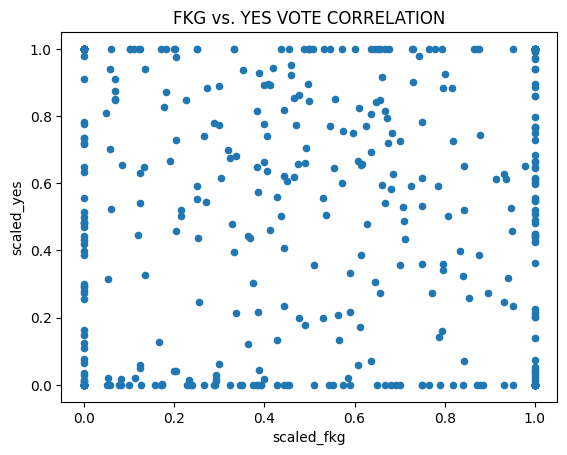

In [ ]:
adf[['scaled_fkg', 'scaled_yes']].plot.scatter(x='scaled_fkg', y='scaled_yes', title='FKG vs. YES VOTE CORRELATION')

Positive statistic means positive correlation

Negative statistic would mean negative correlation (e.g. as complexity goes up, margin of victory goes down)

pvalue < 0.05 means statistically significant correlation

In [ ]:
print('DALE CHALL VS. MARGIN OF VICTORY CORRELATION')
pearsonr(adf.scaled_dc, adf.scaled_win)
print('FKG VS. MARGIN OF VICTORY CORRELATION')
pearsonr(adf.scaled_fkg, adf.scaled_win)

DALE CHALL VS. MARGIN OF VICTORY CORRELATION


PearsonRResult(statistic=0.014027239246986553, pvalue=0.7140102834879065)

FKG VS. MARGIN OF VICTORY CORRELATION


PearsonRResult(statistic=0.1626588071118354, pvalue=1.8863548135856632e-05)

pvalue < 0.05 means statistically significant correlation


In [ ]:
print('DALE CHALL VS. YES VOTE CORRELATION')
pearsonr(adf.scaled_dc, adf.scaled_yes)
print('FKG VS. YES VOTE CORRELATION')
pearsonr(adf.scaled_fkg, adf.scaled_yes)
print('DALE CHALL VS. TURNOUT CORRELATION')
pearsonr(adf.scaled_dc, adf.scaled_turnout)
print('FKG VS. TURNOUT CORRELATION')
pearsonr(adf.scaled_fkg, adf.scaled_turnout)

DALE CHALL VS. YES VOTE CORRELATION


PearsonRResult(statistic=-0.024739741154286985, pvalue=0.5180090964434153)

FKG VS. YES VOTE CORRELATION


PearsonRResult(statistic=0.17112894792524064, pvalue=6.669935036871822e-06)

DALE CHALL VS. TURNOUT CORRELATION


PearsonRResult(statistic=-0.07963112279100307, pvalue=0.037192083842426484)

FKG VS. TURNOUT CORRELATION


PearsonRResult(statistic=0.10285804259874348, pvalue=0.007053978012838091)

Findings:

    * High Dale-Chall associated with lower turnout (weak)
    * High FKG associated with higher turnout (somewhat strong)
    * High FKG associated with higher yes vote (strong)